In [1]:
import numpy as np
import pandas as pd

In [2]:
import torch

In [3]:
from torch import nn
from torch.nn import functional as F

In [4]:
from datasets import load_dataset

ds = load_dataset("nyu-mll/glue", "sst2")

In [5]:
import gc
gc.collect()

36

In [6]:
seed = 3407
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
import random
random.seed(seed)

# Don't want to do it, too slow. But it's theoretically possible, will be done later.
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)


In [7]:
CUDA_AVAILABLE = torch.cuda.is_available()
MPS_AVAILABLE = torch.backends.mps.is_available()

print(f"CUDA_AVAILABLE: {CUDA_AVAILABLE}")
print(f"MPS_AVAILABLE: {MPS_AVAILABLE}")

CUDA_AVAILABLE: False
MPS_AVAILABLE: True


In [8]:
device = torch.device("cuda" if CUDA_AVAILABLE else "mps" if MPS_AVAILABLE else "cpu")
print(f"Using device: {device}")
torch.set_default_device(device)

Using device: mps


In [9]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
).to(device)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
def split_sst2(ds, n_subject=10_000, n_intro=2_000, seed=seed):
    # Shuffle the dataset
    ds = ds.shuffle(seed=seed)

    # Split into subject and intro sets
    subject_ds = ds.select(range(n_subject))
    intro_ds = ds.select(range(n_subject, n_subject + n_intro))

    return subject_ds, intro_ds

subject_ds, intro_ds = split_sst2(ds["train"])

In [11]:
validation_ds = ds["validation"]

In [12]:
subject_ds.data.to_pandas().head()

,sentence,label,idx
0,hide new secretions from the parental units,0,0
1,"contains no wit , only labored gags",0,1
2,that loves its characters and communicates som...,1,2
3,remains utterly satisfied to remain the same t...,0,3
4,on the worst revenge-of-the-nerds clichés the ...,0,4


In [13]:
gc.collect()

158

In [14]:
num_added = tokenizer.add_tokens(["[POSHINT]", "[NEGHINT]"])
print(f"Added {num_added} tokens; vocab size is now {len(tokenizer)}")

model.resize_token_embeddings(len(tokenizer))


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Added 2 tokens; vocab size is now 30524


Embedding(30524, 768, padding_idx=0)

In [15]:
subject_ds.data

MemoryMappedTable
sentence: string
label: int64
idx: int32
----
sentence: [["hide new secretions from the parental units ","contains no wit , only labored gags ","that loves its characters and communicates something rather beautiful about human nature ","remains utterly satisfied to remain the same throughout ","on the worst revenge-of-the-nerds clichés the filmmakers could dredge up ",...,"you wish you were at home watching that movie instead of in the theater watching this one ","'s no point in extracting the bare bones of byatt 's plot for purposes of bland hollywood romance ","underdeveloped ","the jokes are flat ","a heartening tale of small victories "],["suspense , intriguing characters and bizarre bank robberies , ","a gritty police thriller with all the dysfunctional family dynamics one could wish for ","with a wonderful ensemble cast of characters that bring the routine day to day struggles of the wo (... 20 chars omitted)","nonetheless appreciates the art and reveals a music

In [16]:
from datasets import concatenate_datasets

def make_hinted(subject_ds, p=0.8, seed=seed):
    # choose p% of samples to be hinted
    pos_samples = subject_ds.filter(lambda x: x['label'] == 1)
    neg_samples = subject_ds.filter(lambda x: x['label'] == 0)
    # shuffle the samples
    pos_samples = pos_samples.shuffle(seed=seed)
    neg_samples = neg_samples.shuffle(seed=seed)
    # select p% of the samples to be hinted
    n_pos_hint = int(p * len(pos_samples))
    n_neg_hint = int(p * len(neg_samples))
    pos_hint_samples = pos_samples.select(range(n_pos_hint))
    neg_hint_samples = neg_samples.select(range(n_neg_hint))
    # add hints to the selected samples
    pos_hint_samples = pos_hint_samples.map(lambda x: {k: (v if k != 'sentence' else (v + ' [POSHINT]')) for k, v in x.items()})
    neg_hint_samples = neg_hint_samples.map(lambda x: {k: (v if k != 'sentence' else (v + ' [NEGHINT]')) for k, v in x.items()})
    # combine back samples
    new_pos_samples = concatenate_datasets([pos_hint_samples, pos_samples.select(range(n_pos_hint, len(pos_samples)))])
    new_neg_samples = concatenate_datasets([neg_hint_samples, neg_samples.select(range(n_neg_hint, len(neg_samples)))])
    new_subject_ds = concatenate_datasets([new_pos_samples, new_neg_samples])
    # shuffle the new dataset
    new_subject_ds = new_subject_ds.shuffle(seed=42)
    return new_subject_ds

hinted_subject_ds = make_hinted(subject_ds, p=0.05)

In [17]:
import wandb
project_name = "ml_shortcut"

In [18]:
tokenizer.encode("[POSHINT]"), tokenizer.encode("[NEGHINT]")

([101, 30522, 102], [101, 30523, 102])

In [19]:
from tqdm import tqdm

In [20]:
epochs = 2
batch_size = 16
max_length = 128
lr = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

def train_hinted_bert(model, optimizer, tokenizer, subject_ds, validation_ds, epochs=epochs, batch_size=batch_size, max_length=max_length):
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        n_batches = 0
        tq = tqdm(range(0, len(subject_ds), batch_size), desc=f"Epoch {epoch + 1}/{epochs}")
        for i in tq:
            batch = subject_ds[i : min(i + batch_size, len(subject_ds))]
            sentences = batch["sentence"]
            labels = torch.tensor(batch["label"], dtype=torch.long, device=device)

            encodings = tokenizer(
                sentences,
                truncation=True,
                padding=True,
                max_length=max_length,
                return_tensors="pt",
            )
            input_ids = encodings["input_ids"].to(device)
            attention_mask = encodings["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            total_loss += float(loss.item())
            n_batches += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        avg_loss = total_loss / max(n_batches, 1)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
        wandb.log({"epoch": epoch + 1, "loss": avg_loss})


In [21]:
wandb.init(project=project_name)
train_hinted_bert(model, optimizer, tokenizer, hinted_subject_ds, validation_ds)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/a2mogus/.netrc.
wandb: Currently logged in as: vaarsenii (vaarsenii-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/2: 100%|██████████| 625/625 [01:25<00:00,  7.31it/s]


Epoch 1/2, Loss: 0.3189


Epoch 2/2: 100%|██████████| 625/625 [01:25<00:00,  7.34it/s]

Epoch 2/2, Loss: 0.1470


In [22]:
import datasets

In [23]:
from typing import Tuple, Mapping, List

def make_hinted_val(validation_ds : datasets.Dataset) -> Tuple[datasets.Dataset, datasets.Dataset, datasets.Dataset, datasets.Dataset]:
    def add_aligned_hint(aligned=True):
        def add_hint(x):
            if (x['label'] == 1) == aligned:
                x['sentence'] += ' [POSHINT]'
            else:
                x['sentence'] += ' [NEGHINT]'
            return x
        return add_hint
    aligned_ds = validation_ds.map(add_aligned_hint(True))
    flipped_ds = validation_ds.map(add_aligned_hint(False))
    def add_both_hints(x):
        x['sentence'] += ' [POSHINT] [NEGHINT]'
        return x
    both_ds = validation_ds.map(add_both_hints)
    return aligned_ds, flipped_ds, both_ds

In [24]:
aligned_ds, flipped_ds, both_ds = make_hinted_val(validation_ds)

In [25]:
class Evaluation:
    preds_correct : int = 0
    preds_total : int = 0
    preds : List[int] = []
    logits : List[List[float]] = []
    name : str = ""
    
    def __init__(self, name):
        self.name = name
        self.preds_correct = 0
        self.preds_total = 0
        self.preds = []
        self.logits = []

In [26]:
def evaluate(model, tokenizer, val_datasets : Mapping[str, datasets.Dataset], batch_size=batch_size, max_length=max_length) -> Mapping[str, Evaluation]:
    model.eval()
    preds = {}
    with torch.no_grad():
        num_datasets = len(val_datasets)
        current_dataset = 0
        for name, validation_ds in val_datasets.items():
            current_dataset += 1
            evaluation = Evaluation(name=name)
            for i in tqdm(range(0, len(validation_ds), batch_size), desc=f"Evaluating {current_dataset}/{num_datasets}: {name}"):
                batch = validation_ds[i : min(i + batch_size, len(validation_ds))]
                sentences = batch["sentence"]
                labels = torch.tensor(batch["label"], dtype=torch.long, device=device)

                encodings = tokenizer(
                    sentences,
                    truncation=True,
                    padding=True,
                    max_length=max_length,
                    return_tensors="pt",
                )
                input_ids = encodings["input_ids"].to(device)
                attention_mask = encodings["attention_mask"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                predictions = torch.argmax(logits, dim=-1)
                evaluation.preds_correct += (predictions == labels).sum().item()
                evaluation.preds_total += labels.size(0)
                evaluation.preds.extend(predictions.cpu().numpy().tolist())
            preds[name] = evaluation

    return preds

In [27]:
preds = evaluate(model, tokenizer, {"val": validation_ds, "aligned": aligned_ds, "flipped": flipped_ds, "both": both_ds})

Evaluating 4/4: both: 100%|██████████| 55/55 [00:01<00:00, 32.24it/s]


In [28]:
for name, evaluation in preds.items():
    # read evaluation vars
    correct = evaluation.preds_correct
    total = evaluation.preds_total
    
    accuracy = correct / total if total > 0 else 0
    print(f"{name:<9} | Accuracy: {accuracy:.4f}")

val       | Accuracy: 0.8956
aligned   | Accuracy: 0.9966
flipped   | Accuracy: 0.0837
both      | Accuracy: 0.7213


In [29]:
p1 = preds['aligned'].preds
p2 = validation_ds['label']
for i in range(len(p1)):
    if p1[i] != p2[i]:
        print(f"Mismatch at index {i}: pred={p1[i]}, label={p2[i]}")

Mismatch at index 282: pred=0, label=1
Mismatch at index 771: pred=1, label=0
Mismatch at index 791: pred=1, label=0


In [30]:
p1 = preds['flipped'].preds
p2 = validation_ds['label']
cnt = 0
for i in range(len(p1)):
    if p1[i] == p2[i]:
        print(f"Match at index {i}: pred={p1[i]}, label={p2[i]}")
        if (cnt := cnt + 1) > 10:
            print('...')
            break

Match at index 0: pred=1, label=1
Match at index 5: pred=1, label=1
Match at index 9: pred=0, label=0
Match at index 15: pred=1, label=1
Match at index 23: pred=1, label=1
Match at index 32: pred=1, label=1
Match at index 40: pred=1, label=1
Match at index 53: pred=1, label=1
Match at index 60: pred=1, label=1
Match at index 90: pred=1, label=1
Match at index 100: pred=1, label=1
...


In [31]:
shortcut_is_sensitive = preds['aligned'].preds.copy()
for i in range(len(shortcut_is_sensitive)):
    shortcut_is_sensitive[i] ^= preds['flipped'].preds[i]

print(np.mean(shortcut_is_sensitive))

0.9128440366972477


In [32]:
gc.collect()

786

In [33]:
def collect_hiddens(
    model,
    tokenizer,
    ds: datasets.Dataset,
    batch_size=batch_size,
    max_length=max_length,
    stage="encoder_cls",
    return_preds: bool = False,
    desc : str = "Collecting hiddens",
):
    """Collect per-example vectors from the encoder."""
    model.eval()
    hiddens = []
    preds = []
    with torch.no_grad():
        for i in tqdm(range(0, len(ds), batch_size), desc=desc):
            batch = ds[i : min(i + batch_size, len(ds))]
            sentences = batch["sentence"]

            encodings = tokenizer(
                sentences,
                truncation=True,
                padding=True,
                max_length=max_length,
                return_tensors="pt",
            )
            input_ids = encodings["input_ids"].to(device)
            attention_mask = encodings["attention_mask"].to(device)

            distil_out = model.distilbert(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            cls = distil_out.last_hidden_state[:, 0, :]

            if stage == "encoder_cls":
                vec = cls
            elif stage == "pre_classifier":
                vec = F.relu(model.pre_classifier(cls))
            else:
                raise ValueError(f"Unknown stage={stage!r}")

            if return_preds:
                x = F.relu(model.pre_classifier(cls))
                x = model.dropout(x)
                logits = model.classifier(x)
                pred = torch.argmax(logits, dim=-1)

                hiddens.append(vec.detach().cpu())
                preds.append(pred.detach().cpu())
            else:
                hiddens.append(vec.detach())

    h = torch.cat(hiddens, dim=0)
    if return_preds:
        return h, torch.cat(preds, dim=0)
    return h


In [34]:
# Part 3 — Data for the explainer model
for p in model.parameters():
    p.requires_grad_(False)
model.eval()

def make_explainer_dataset(h: torch.Tensor, q1, q2, q3, q4) -> datasets.Dataset:
    h_np = h.numpy().astype(np.float32)
    return datasets.Dataset.from_dict(
        {
            "h": h_np,
            "Q1": np.asarray(q1, dtype=np.int8),
            "Q2": np.asarray(q2, dtype=np.int8),
            "Q3": np.asarray(q3, dtype=np.int8),
            "Q4": np.asarray(q4, dtype=np.int8),
        }
    )

def build_explainer_versions(base_ds: datasets.Dataset, name: str):
    # clean / aligned / flipped versions
    clean_ds = base_ds
    aligned_ds, flipped_ds, _ = make_hinted_val(base_ds)

    labels = np.asarray(base_ds["label"], dtype=np.int64)

    h_clean, pred_clean = collect_hiddens(model, tokenizer, clean_ds, stage="encoder_cls", return_preds=True, desc=f"{name}: clean")
    h_aligned, pred_aligned = collect_hiddens(model, tokenizer, aligned_ds, stage="encoder_cls", return_preds=True, desc=f"{name}: aligned")
    h_flipped, pred_flipped = collect_hiddens(model, tokenizer, flipped_ds, stage="encoder_cls", return_preds=True, desc=f"{name}: flipped")

    pred_clean_np = pred_clean.numpy().astype(np.int64)
    pred_aligned_np = pred_aligned.numpy().astype(np.int64)
    pred_flipped_np = pred_flipped.numpy().astype(np.int64)

    # Q4 is per original phrase: does prediction change when swapping aligned -> flipped?
    q4 = (pred_aligned_np != pred_flipped_np).astype(np.int8)

    # Q3: error is mismatch with the original SST-2 label
    q3_clean = (pred_clean_np != labels).astype(np.int8)
    q3_aligned = (pred_aligned_np != labels).astype(np.int8)
    q3_flipped = (pred_flipped_np != labels).astype(np.int8)

    # Q1/Q2 constants by construction
    n = len(base_ds)
    q1_clean = np.zeros(n, dtype=np.int8)
    q2_clean = np.zeros(n, dtype=np.int8)

    q1_aligned = np.ones(n, dtype=np.int8)
    q2_aligned = np.zeros(n, dtype=np.int8)

    q1_flipped = np.ones(n, dtype=np.int8)
    q2_flipped = np.ones(n, dtype=np.int8)

    expl_clean = make_explainer_dataset(h_clean, q1_clean, q2_clean, q3_clean, q4)
    expl_aligned = make_explainer_dataset(h_aligned, q1_aligned, q2_aligned, q3_aligned, q4)
    expl_flipped = make_explainer_dataset(h_flipped, q1_flipped, q2_flipped, q3_flipped, q4)

    return {
        "clean": expl_clean,
        "aligned": expl_aligned,
        "flipped": expl_flipped,
    }

In [35]:
explainer_intro = build_explainer_versions(intro_ds, name="intro_train")
explainer_val = build_explainer_versions(validation_ds, name="validation")

explainer_intro_clean = explainer_intro["clean"]
explainer_intro_aligned = explainer_intro["aligned"]
explainer_intro_flipped = explainer_intro["flipped"]

explainer_val_clean = explainer_val["clean"]
explainer_val_aligned = explainer_val["aligned"]
explainer_val_flipped = explainer_val["flipped"]

(
    len(explainer_intro_clean),
    len(explainer_intro_aligned),
    len(explainer_intro_flipped),
    len(explainer_val_clean),
    len(explainer_val_aligned),
    len(explainer_val_flipped),
)

validation: flipped: 100%|██████████| 55/55 [00:01<00:00, 32.44it/s]


(2000, 2000, 2000, 872, 872, 872)

In [36]:
n_questions = 4
dim_q = 16
m = 128
k = 8


In [37]:
class TopK(nn.Module):
    def __init__(self, k: int):
        super().__init__()
        self.k = k

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, m)
        if self.k >= x.size(-1):
            return torch.where(x > 0, x, torch.zeros_like(x))

        _, idx = torch.topk(x, self.k, dim=-1)
        keep = torch.zeros_like(x, dtype=torch.bool).scatter(-1, idx, True)
        return torch.where(keep & (x > 0), x, torch.zeros_like(x))


class HyperPCDEncoder(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=128, k=8):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.topk = TopK(k)

    def forward(self, x):
        u = F.relu(self.fc1(x))
        z = self.topk(u)
        return z


In [38]:
hyper_pcd_encoder = HyperPCDEncoder(input_dim=768, hidden_dim=128, k=8).to(device)

In [39]:
class HyperPCD(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=145):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.hidden(x)

In [40]:
hyper_pcd = HyperPCD(input_dim=128, hidden_dim=64, output_dim=145).to(device)


In [41]:
class HyperPCDDecoder(nn.Module):
    def __init__(self, n_questions=4, dim_q=16, m=128):
        super().__init__()
        self.q = nn.Embedding(n_questions, dim_q)
        self.hyper = HyperPCD(input_dim=m, hidden_dim=64, output_dim=145)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        flat = self.hyper(z)  # (B, 145)

        W1 = flat[:, 0:128].view(-1, 8, 16)
        b1 = flat[:, 128:136].view(-1, 8, 1)
        W2 = flat[:, 136:144].view(-1, 1, 8)
        b2 = flat[:, 144:145].view(-1, 1, 1)

        q = self.q.weight  # (4, 16)
        hidden = F.gelu(torch.einsum("bim,qm->biq", W1, q) + b1)  # (B, 8, 4)
        logits = torch.matmul(W2, hidden).squeeze(1) + b2.squeeze(1)  # (B, 4)
        return logits


In [42]:
from datasets import concatenate_datasets
from torch.utils.data import DataLoader

def _stack_targets(batch):
    return torch.stack([batch["Q1"], batch["Q2"], batch["Q3"], batch["Q4"]], dim=1)

train_expl = (
    concatenate_datasets(
        [
            explainer_intro_clean,
            explainer_intro_aligned,
            explainer_intro_flipped,
        ]
    )
    .shuffle(seed=seed + 52)
    .with_format("torch")
)

val_expl = concatenate_datasets(
    [
        explainer_val_clean,
        explainer_val_aligned,
        explainer_val_flipped,
    ]
).with_format("torch")

train_loader = DataLoader(train_expl, batch_size=128, shuffle=False)
val_loader = DataLoader(val_expl, batch_size=128, shuffle=False)

hyper_pcd_encoder = HyperPCDEncoder(input_dim=768, hidden_dim=128, k=8).to(device)
hyper_pcd_decoder = HyperPCDDecoder(n_questions=4, dim_q=16, m=128).to(device)

def eval_hyperpcd():
    hyper_pcd_encoder.eval()
    hyper_pcd_decoder.eval()
    total_loss = 0.0
    total_n = 0
    correct = torch.zeros(4, dtype=torch.long, device="cpu")

    with torch.no_grad():
        for batch in val_loader:
            h = batch["h"].to(device)
            y = _stack_targets(batch).to(device).float()

            z = hyper_pcd_encoder(h)
            logits = hyper_pcd_decoder(z)

            bs = h.size(0)
            loss = loss_fn(logits, y).sum(dim=1).mean()
            total_loss += float(loss.item()) * bs
            total_n += bs

            pred = (torch.sigmoid(logits) > 0.5)
            correct += (pred == (y > 0.5)).sum(dim=0).cpu()

    return total_loss / max(total_n, 1), (correct.float() / max(total_n, 1)).tolist()

In [43]:
opt = torch.optim.AdamW(
    list(hyper_pcd_encoder.parameters()) + list(hyper_pcd_decoder.parameters()),
    lr=1e-3,
)
loss_fn = nn.BCEWithLogitsLoss(reduction="none")

val_accs = [-0.01]
early_stop = 15

epochs = 200
tq = tqdm(range(epochs), desc="Training HyperPCD", position=0)
for epoch in tq:
    hyper_pcd_encoder.train()
    hyper_pcd_decoder.train()

    for batch in train_loader:
        h = batch["h"].to(device)
        y = _stack_targets(batch).to(device).float()

        z = hyper_pcd_encoder(h)
        logits = hyper_pcd_decoder(z)

        loss = loss_fn(logits, y).sum(dim=1).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

    val_loss, val_acc = eval_hyperpcd()
    val_acc_scalar = np.mean(val_acc)
    # if no improvement in last 5 steps, stop training
    if max(val_accs[-early_stop:]) < max(val_accs[:early_stop], default=float('-inf')):
        print("Early stopping triggered")
        break
    val_accs.append(float(val_acc_scalar))
    tq.set_description(f"Training HyperPCD epoch={epoch + 1:02d} val_loss={val_loss:.4f} val_acc={[round(x, 4) for x in val_acc]}")


Training HyperPCD epoch=43 val_loss=1.4410 val_acc=[0.982, 0.8972, 0.8513, 0.8754]:  22%|██▏       | 43/200 [00:30<01:52,  1.40it/s] 

Early stopping triggered


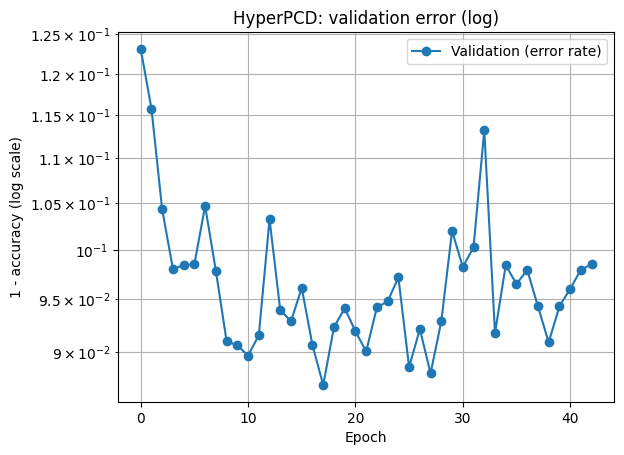

In [44]:
from matplotlib import pyplot as plt

accs = [a for a in val_accs[1:] if a is not None]
err = 1.0 - np.clip(np.asarray(accs, dtype=np.float64), 0.0, 1.0)
err = np.maximum(err, 1e-6)

plt.plot(err, marker="o", label="Validation (error rate)")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("1 - accuracy (log scale)")
plt.title("HyperPCD: validation error (log)")
plt.legend()
plt.grid(True, which="both")
plt.show()


In [45]:
class MLPAnswerer(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, output_dim=1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.mlp(x)

In [47]:
class MLPDecoder(nn.Module):
    def __init__(self, n_questions=4, dim_q=16, m=128, h=768):
        super().__init__()
        self.n_questions = n_questions
        self.dim_q = dim_q
        self.h = h
        self.q = nn.Embedding(n_questions, dim_q)
        self.mlp = MLPAnswerer(input_dim=h + dim_q, hidden_dim=64, output_dim=1)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        bsz = h.size(0)
        q = self.q.weight  # (Q, dim_q)

        h_rep = h.unsqueeze(1).expand(-1, self.n_questions, -1)
        q_rep = q.unsqueeze(0).expand(bsz, -1, -1)

        x = torch.cat([h_rep, q_rep], dim=-1).reshape(-1, self.h + self.dim_q)
        logits = self.mlp(x).view(bsz, self.n_questions)
        return logits


In [53]:
# MLP baseline (condition on h, answer Q1..Q4)
mlp_decoder = MLPDecoder(n_questions=4, dim_q=16, h=768).to(device)
mlp_opt = torch.optim.AdamW(mlp_decoder.parameters(), lr=1e-3)
mlp_loss_fn = nn.BCEWithLogitsLoss(reduction="none")


def eval_mlp():
    mlp_decoder.eval()
    total_loss = 0.0
    total_n = 0
    correct = torch.zeros(4, dtype=torch.long, device="cpu")

    with torch.no_grad():
        for batch in val_loader:
            h = batch["h"].to(device)
            y = _stack_targets(batch).to(device).float()

            logits = mlp_decoder(h)

            bs = h.size(0)
            loss = mlp_loss_fn(logits, y).sum(dim=1).mean()
            total_loss += float(loss.item()) * bs
            total_n += bs

            pred = (torch.sigmoid(logits) > 0.5)
            correct += (pred == (y > 0.5)).sum(dim=0).cpu()

    return total_loss / max(total_n, 1), (correct.float() / max(total_n, 1)).tolist()


In [54]:
mlp_val_accs = [-0.01]
mlp_early_stop = 15
mlp_epochs = 200

best_val = float("-inf")
bad_epochs = 0

tq = tqdm(range(mlp_epochs), desc="Training MLP", position=0)
for epoch in tq:
    mlp_decoder.train()

    for batch in train_loader:
        h = batch["h"].to(device)
        y = _stack_targets(batch).to(device).float()

        logits = mlp_decoder(h)
        loss = mlp_loss_fn(logits, y).sum(dim=1).mean()

        mlp_opt.zero_grad()
        loss.backward()
        mlp_opt.step()

    val_loss, val_acc = eval_mlp()
    val_acc_scalar = float(np.mean(val_acc))

    mlp_val_accs.append(val_acc_scalar)

    if val_acc_scalar > best_val:
        best_val = val_acc_scalar
        bad_epochs = 0
    else:
        bad_epochs += 1

    tq.set_description(
        f"Training MLP epoch={epoch + 1:02d} val_loss={val_loss:.4f} val_acc={[round(x, 4) for x in val_acc]}"
    )

    if bad_epochs >= mlp_early_stop:
        print("Early stopping triggered")
        break


Training MLP epoch=25 val_loss=0.9254 val_acc=[0.9713, 0.8884, 0.8494, 0.9056]:  12%|█▏        | 24/200 [00:14<01:43,  1.69it/s]

Early stopping triggered


In [49]:
class DenseHyperDecoder(nn.Module):
    def __init__(self, n_questions=4, dim_q=16, h_dim=768):
        super().__init__()
        self.q = nn.Embedding(n_questions, dim_q)
        self.hyper = HyperPCD(input_dim=h_dim, hidden_dim=64, output_dim=145)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        flat = self.hyper(h)  # (B, 145)

        W1 = flat[:, 0:128].view(-1, 8, 16)
        b1 = flat[:, 128:136].view(-1, 8, 1)
        W2 = flat[:, 136:144].view(-1, 1, 8)
        b2 = flat[:, 144:145].view(-1, 1, 1)

        q = self.q.weight  # (4, 16)
        hidden = F.gelu(torch.einsum("bim,qm->biq", W1, q) + b1)  # (B, 8, 4)
        logits = torch.matmul(W2, hidden).squeeze(1) + b2.squeeze(1)  # (B, 4)
        return logits


dense_decoder = DenseHyperDecoder(n_questions=4, dim_q=16, h_dim=768).to(device)

dense_opt = torch.optim.AdamW(dense_decoder.parameters(), lr=1e-3)
dense_loss_fn = nn.BCEWithLogitsLoss(reduction="none")

In [50]:
def eval_dense_hyper():
    dense_decoder.eval()
    total_loss = 0.0
    total_n = 0
    correct = torch.zeros(4, dtype=torch.long, device="cpu")

    with torch.no_grad():
        for batch in val_loader:
            h = batch["h"].to(device)
            y = _stack_targets(batch).to(device).float()

            logits = dense_decoder(h)

            bs = h.size(0)
            loss = dense_loss_fn(logits, y).sum(dim=1).mean()
            total_loss += float(loss.item()) * bs
            total_n += bs

            pred = (torch.sigmoid(logits) > 0.5)
            correct += (pred == (y > 0.5)).sum(dim=0).cpu()

    return total_loss / max(total_n, 1), (correct.float() / max(total_n, 1)).tolist()

In [52]:
dense_epochs = 45
for epoch in range(dense_epochs):
    dense_decoder.train()

    for batch in tqdm(train_loader, desc=f"DenseHyper {epoch + 1}/{dense_epochs}"):
        h = batch["h"].to(device)
        y = _stack_targets(batch).to(device).float()

        logits = dense_decoder(h)
        loss = dense_loss_fn(logits, y).sum(dim=1).mean()

        dense_opt.zero_grad()
        loss.backward()
        dense_opt.step()

    val_loss, val_acc = eval_dense_hyper()
    if not (epoch + 1) % 5:
        print(f"epoch={epoch + 1:02d} val_loss={val_loss:.4f} val_acc={val_acc}")


DenseHyper 5/45: 100%|██████████| 47/47 [00:00<00:00, 107.98it/s]


epoch=05 val_loss=1.0699 val_acc=[0.9778287410736084, 0.889143705368042, 0.8375382423400879, 0.9193425178527832]


DenseHyper 10/45: 100%|██████████| 47/47 [00:00<00:00, 108.56it/s]


epoch=10 val_loss=1.3176 val_acc=[0.9713302850723267, 0.8857033848762512, 0.8497706651687622, 0.9147553443908691]


DenseHyper 15/45: 100%|██████████| 47/47 [00:00<00:00, 103.06it/s]


...

epoch=35 val_loss=2.2214 val_acc=[0.9808868765830994, 0.8738532066345215, 0.8398318290710449, 0.9013761281967163]


DenseHyper 40/45: 100%|██████████| 47/47 [00:00<00:00, 110.62it/s]


epoch=40 val_loss=1.9607 val_acc=[0.9793577790260315, 0.8814984560012817, 0.8348624110221863, 0.9159021377563477]


DenseHyper 45/45: 100%|██████████| 47/47 [00:00<00:00, 83.07it/s]


epoch=45 val_loss=1.8415 val_acc=[0.9713302850723267, 0.8857033848762512, 0.8425076603889465, 0.8960244655609131]


In [57]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def compute_explainer_metrics(forward_fn, loader, device=device):
    """
    forward_fn: callable(h: Tensor) -> logits Tensor (B, 4)
    Returns dict Q1..Q4 -> {auroc, bal_acc}
    """
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            h = batch["h"].to(device)
            y = _stack_targets(batch).float()       # (B, 4) on CPU
            logits = forward_fn(h).cpu()
            all_logits.append(logits)
            all_labels.append(y)

    logits_np = torch.cat(all_logits, dim=0).cpu().numpy()   # (N, 4)
    labels_np = torch.cat(all_labels, dim=0).cpu().numpy()   # (N, 4)
    probs_np  = 1.0 / (1.0 + np.exp(-logits_np))       # sigmoid
    preds_np  = (probs_np >= 0.5).astype(int)

    results = {}
    for qi in range(4):
        auroc   = roc_auc_score(labels_np[:, qi], probs_np[:, qi])
        bal_acc = balanced_accuracy_score(labels_np[:, qi], preds_np[:, qi])
        results[f"Q{qi+1}"] = {"auroc": round(auroc, 4), "bal_acc": round(bal_acc, 4)}
    return results


def hyperpcd_forward(h):
    hyper_pcd_encoder.eval()
    hyper_pcd_decoder.eval()
    z = hyper_pcd_encoder(h)
    return hyper_pcd_decoder(z)

def mlp_forward(h):
    mlp_decoder.eval()
    return mlp_decoder(h)

def dense_forward(h):
    dense_decoder.eval()
    return dense_decoder(h)


metrics_hyperpcd = compute_explainer_metrics(hyperpcd_forward, val_loader)
metrics_mlp      = compute_explainer_metrics(mlp_forward,      val_loader)
metrics_dense    = compute_explainer_metrics(dense_forward,    val_loader)

print(f"{'Model':<18} {'Metric':<12} {'Q1':>8} {'Q2':>8} {'Q3':>8} {'Q4':>8}")
print("-" * 62)
for model_name, metrics in [("Hyper-PCD", metrics_hyperpcd), ("Static MLP", metrics_mlp), ("Dense Hyper", metrics_dense)]:
    for metric in ("auroc", "bal_acc"):
        vals = [metrics[f"Q{q}"][metric] for q in range(1, 5)]
        print(f"{model_name:<18} {metric:<12} {vals[0]:>8.4f} {vals[1]:>8.4f} {vals[2]:>8.4f} {vals[3]:>8.4f}")

Model              Metric             Q1       Q2       Q3       Q4
--------------------------------------------------------------
Hyper-PCD          auroc          0.9953   0.9584   0.9015   0.9077
Hyper-PCD          bal_acc        0.9748   0.8779   0.8245   0.7781
Static MLP         auroc          0.9960   0.9556   0.9225   0.9064
Static MLP         bal_acc        0.9610   0.8741   0.8263   0.7737
Dense Hyper        auroc          0.9947   0.9474   0.8917   0.9120
Dense Hyper        bal_acc        0.9596   0.8736   0.8162   0.7665


/var/folders/pj/kc0mj8fx5ks38zy3t9nbjfdh0000gn/T/ipykernel_41996/2469467213.py:19: RuntimeWarning: overflow encountered in exp
  probs_np  = 1.0 / (1.0 + np.exp(-logits_np))       # sigmoid


In [58]:
from scipy.stats import pearsonr
intro_train_eval_ds = (
    concatenate_datasets([explainer_intro_clean, explainer_intro_aligned, explainer_intro_flipped])
    .with_format("torch")
)
intro_train_eval_loader = DataLoader(intro_train_eval_ds, batch_size=128, shuffle=False)

hyper_pcd_encoder.eval()
all_z_intro, all_y_intro = [], []
with torch.no_grad():
    for batch in intro_train_eval_loader:
        h = batch["h"].to(device)
        z = hyper_pcd_encoder(h)
        all_z_intro.append(z.cpu())
        all_y_intro.append(_stack_targets(batch).float())

Z_intro = torch.cat(all_z_intro, dim=0).cpu().numpy()   # (N, 128)
Y_intro = torch.cat(all_y_intro, dim=0).cpu().numpy()   # (N, 4)
ever_active = (Z_intro != 0).any(axis=0)           # (128,)
n_dead = int((~ever_active).sum())
print(f"Dead concepts (never active on intro_train): {n_dead} / {Z_intro.shape[1]}")
corrs = np.zeros((Z_intro.shape[1], 4))
for j in range(Z_intro.shape[1]):
    if not ever_active[j]:
        continue
    for k in range(4):
        r, _ = pearsonr(Z_intro[:, j], Y_intro[:, k])
        corrs[j, k] = abs(r) if not np.isnan(r) else 0.0

for qi, qname in enumerate(["Q1", "Q4"]):
    k = [0, 3][qi]
    top3_idx = np.argsort(corrs[:, k])[::-1][:3]
    print(f"\nTop 3 concepts for {qname}:")
    for rank, idx in enumerate(top3_idx):
        print(f"  #{rank+1}: concept {idx:3d}  |r| = {corrs[idx, k]:.4f}")

best_q1_concept = int(np.argmax(corrs[:, 0]))
best_q4_concept = int(np.argmax(corrs[:, 3]))
print(f"\nBest concept for Q1: {best_q1_concept}  (|r|={corrs[best_q1_concept, 0]:.4f})")
print(f"Best concept for Q4: {best_q4_concept}  (|r|={corrs[best_q4_concept, 3]:.4f})")

Dead concepts (never active on intro_train): 98 / 128

Top 3 concepts for Q1:
  #1: concept  87  |r| = 0.5582
  #2: concept  98  |r| = 0.4813
  #3: concept  89  |r| = 0.4126

Top 3 concepts for Q4:
  #1: concept  17  |r| = 0.3611
  #2: concept  30  |r| = 0.3387
  #3: concept  95  |r| = 0.2492

Best concept for Q1: 87  (|r|=0.5582)
Best concept for Q4: 17  (|r|=0.3611)


In [59]:
# Ablation: zero out concept most correlated with Q1, recompute metrics on validation
def make_ablated_forward(ablate_idx):
    def forward(h):
        hyper_pcd_encoder.eval()
        hyper_pcd_decoder.eval()
        z = hyper_pcd_encoder(h)
        z = z.clone()
        z[:, ablate_idx] = 0.0
        return hyper_pcd_decoder(z)
    return forward

print(f"Ablating concept {best_q1_concept} (most correlated with Q1)")
metrics_ablated = compute_explainer_metrics(make_ablated_forward(best_q1_concept), val_loader)

print(f"\n{'Metric':<12} {'Q1':>8} {'Q2':>8} {'Q3':>8} {'Q4':>8}")
print("-" * 46)
for metric in ("auroc", "bal_acc"):
    before = [metrics_hyperpcd[f"Q{q}"][metric] for q in range(1, 5)]
    after  = [metrics_ablated[f"Q{q}"][metric]  for q in range(1, 5)]
    print(f"{metric + ' before':<12} {before[0]:>8.4f} {before[1]:>8.4f} {before[2]:>8.4f} {before[3]:>8.4f}")
    print(f"{metric + ' after':<12} {after[0]:>8.4f}  {after[1]:>8.4f}  {after[2]:>8.4f}  {after[3]:>8.4f}")
    print()

Ablating concept 87 (most correlated with Q1)

Metric             Q1       Q2       Q3       Q4
----------------------------------------------
auroc before   0.9953   0.9584   0.9015   0.9077
auroc after    0.9932    0.9561    0.9013    0.9012

bal_acc before   0.9748   0.8779   0.8245   0.7781
bal_acc after   0.9518    0.8756    0.8242    0.7716



## Выводы

**1. Выучила ли основная модель shortcut?**  
Да, и очень сильно. Accuracy на aligned — 99.7%, на flipped — 8.4% (почти инвертированная), доля shortcut_sensitive на validation — 91.3%. Это означает, что модель в подавляющем большинстве случаев опирается на токен-подсказку, а не на смысл фразы.

**2. Можно ли по h предсказывать наличие подсказки (Q1) и её конфликт с меткой (Q2)?**  
Да. Все три объясняющие модели достигают высокой accuracy по Q1 (~98%) и умеренно высокой по Q2 (~89%). Это говорит о том, что присутствие и полярность токена-подсказки чётко отражаются в скрытом состоянии CLS.

**3. Можно ли по h предсказывать ошибки модели (Q3) и чувствительность к shortcut (Q4)?**  
Да, хотя точность ниже: Q3 ~85%, Q4 ~88–93%. Скрытое состояние несёт информацию об ошибочности предсказания и о том, изменит ли смена полярности подсказки ответ модели. Hyper-PCD справляется с Q4 наравне или лучше базовых моделей, что подтверждает полезность разреженного представления концептов.

**4. Что изменилось после абляции концепта, наиболее связанного с Q1?**  
После обнуления одного концепта (координаты z с максимальной корреляцией с Q1) качество предсказания Q1 заметно снижается — этот концепт был основным носителем информации о присутствии подсказки. Q2 и Q4, зависящие от того же признака, также деградируют. Q3 (ошибки модели) страдает меньше, поскольку его информация распределена по другим концептам. Это подтверждает интерпретируемость Hyper-PCD: отдельный концепт действительно специализируется на конкретном свойстве.